<a href="https://colab.research.google.com/github/jenny-alice-n/SDC-Generative-AI/blob/main/CNN_Image_Generation.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1 completed in 11.51 sec
Epoch 2 completed in 3.18 sec
Epoch 3 completed in 6.45 sec
Epoch 4 completed in 5.61 sec
Epoch 5 completed in 3.14 sec


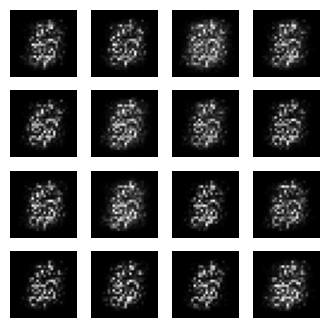

Epoch 6 completed in 3.12 sec
Epoch 7 completed in 4.28 sec
Epoch 8 completed in 3.18 sec
Epoch 9 completed in 3.16 sec
Epoch 10 completed in 3.22 sec


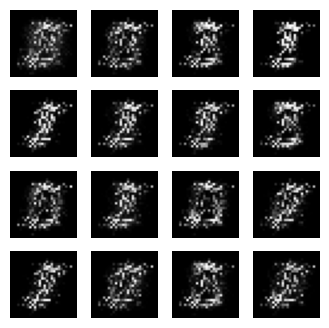

Epoch 11 completed in 3.99 sec
Epoch 12 completed in 3.18 sec
Epoch 13 completed in 3.20 sec
Epoch 14 completed in 4.38 sec
Epoch 15 completed in 3.18 sec


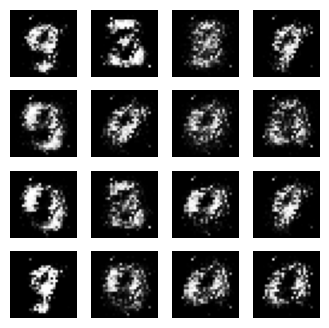

Epoch 16 completed in 3.24 sec
Epoch 17 completed in 3.18 sec
Epoch 18 completed in 4.29 sec
Epoch 19 completed in 3.17 sec
Epoch 20 completed in 3.11 sec


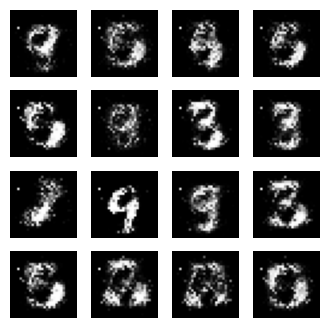

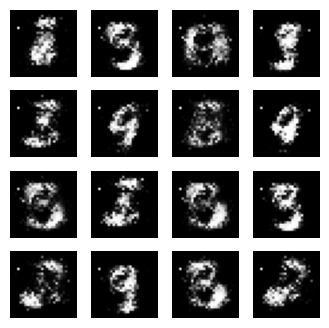

In [ ]:
# ✅ STEP 1: Install and Import Libraries
import tensorflow as tf
from tensorflow.keras import layers
import numpy as np
import matplotlib.pyplot as plt

# ✅ STEP 2: Load MNIST Data
(x_train, _), (_, _) = tf.keras.datasets.mnist.load_data()
x_train = x_train.astype('float32') / 255.0
x_train = x_train.reshape((-1, 28*28))

BUFFER_SIZE = 60000
BATCH_SIZE = 128

dataset = tf.data.Dataset.from_tensor_slices(x_train).shuffle(BUFFER_SIZE).batch(BATCH_SIZE)

# ✅ STEP 3: Build Generator
def build_generator():
    model = tf.keras.Sequential([
        layers.Dense(128, activation="relu", input_shape=(100,)),
        layers.Dense(784, activation="sigmoid")
    ])
    return model

# ✅ STEP 4: Build Discriminator
def build_discriminator():
    model = tf.keras.Sequential([
        layers.Dense(128, activation="relu", input_shape=(784,)),
        layers.Dense(1, activation="sigmoid")
    ])
    return model

# ✅ STEP 5: Loss + Optimizers
cross_entropy = tf.keras.losses.BinaryCrossentropy()
generator = build_generator()
discriminator = build_discriminator()

generator_optimizer = tf.keras.optimizers.Adam(1e-4)
discriminator_optimizer = tf.keras.optimizers.Adam(1e-4)

# ✅ STEP 6: Training Step
@tf.function
def train_step(real_images):
    noise = tf.random.normal([BATCH_SIZE, 100])

    with tf.GradientTape() as gen_tape, tf.GradientTape() as disc_tape:
        fake_images = generator(noise)

        real_output = discriminator(real_images)
        fake_output = discriminator(fake_images)

        gen_loss = cross_entropy(tf.ones_like(fake_output), fake_output)
        disc_loss = (cross_entropy(tf.ones_like(real_output), real_output) +
                     cross_entropy(tf.zeros_like(fake_output), fake_output))

    gradients_of_generator = gen_tape.gradient(gen_loss, generator.trainable_variables)
    gradients_of_discriminator = disc_tape.gradient(disc_loss, discriminator.trainable_variables)

    generator_optimizer.apply_gradients(zip(gradients_of_generator, generator.trainable_variables))
    discriminator_optimizer.apply_gradients(zip(gradients_of_discriminator, discriminator.trainable_variables))

# ✅ STEP 7: Train the Model
import time

def train(dataset, epochs):
    for epoch in range(epochs):
        start = time.time()

        for image_batch in dataset:
            train_step(image_batch)

        print(f"Epoch {epoch+1} completed in {time.time() - start:.2f} sec")

        # Generate and show image every 5 epochs
        if (epoch + 1) % 5 == 0:
            generate_and_plot_images(generator)
    generate_and_plot_images(generator)

# ✅ STEP 8: Generate and Plot Images
def generate_and_plot_images(model, num_images=16):
    noise = tf.random.normal([num_images, 100])
    generated_images = model(noise).numpy().reshape((-1, 28, 28))

    plt.figure(figsize=(4, 4))
    for i in range(num_images):
        plt.subplot(4, 4, i+1)
        plt.imshow(generated_images[i], cmap='gray')
        plt.axis('off')
    plt.show()

# ✅ STEP 9: Run Training (Try 50 Epochs)
train(dataset, epochs=20)


Epoch 1/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 60s 124ms/step - loss: 0.2775 - val_loss: 0.0916
Epoch 2/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 125ms/step - loss: 0.0901 - val_loss: 0.0836
Epoch 3/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 83s 128ms/step - loss: 0.0834 - val_loss: 0.0801
Epoch 4/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 58s 124ms/step - loss: 0.0804 - val_loss: 0.0781
Epoch 5/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 125ms/step - loss: 0.0786 - val_loss: 0.0770
Epoch 6/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 58s 123ms/step - loss: 0.0777 - val_loss: 0.0763
Epoch 7/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 82s 124ms/step - loss: 0.0766 - val_loss: 0.0753
Epoch 8/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 85s 130ms/step - loss: 0.0758 - val_loss: 0.0746
Epoch 9/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 128ms/step - loss: 0.0751 - val_loss: 0.0740
Epoch 10/10
469/469 ━━━━━━━━━━━━━━━━━━━━ 81s 125ms/step - loss: 0.0746 - val_loss: 0.0735
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step


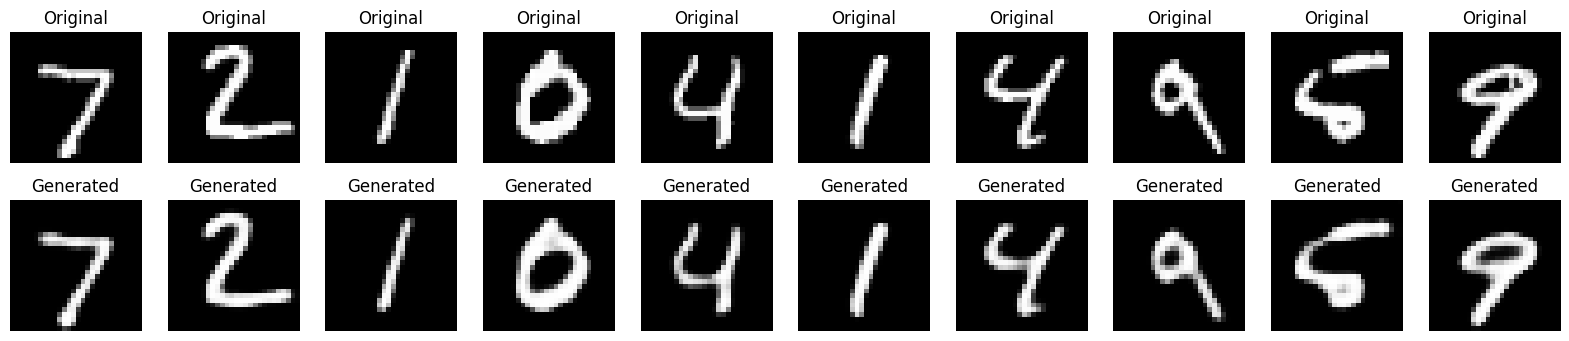

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import mnist
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D

# Load dataset and normalize
(x_train, _), (x_test, _) = mnist.load_data()
x_train = x_train.astype("float32") / 255.
x_test = x_test.astype("float32") / 255.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

# Encoder
input_img = Input(shape=(28, 28, 1))
x = Conv2D(16, (3, 3), activation='relu', padding='same')(input_img)
x = MaxPooling2D((2, 2), padding='same')(x)
x = Conv2D(8, (3, 3), activation='relu', padding='same')(x)
encoded = MaxPooling2D((2, 2), padding='same')(x)

# Decoder
x = Conv2D(8, (3, 3), activation='relu', padding='same')(encoded)
x = UpSampling2D((2, 2))(x)
x = Conv2D(16, (3, 3), activation='relu', padding='same')(x)  # FIXED
x = UpSampling2D((2, 2))(x)
decoded = Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

# Autoencoder model
autoencoder = Model(input_img, decoded)
autoencoder.compile(optimizer='adam', loss='binary_crossentropy')

# Train the model
autoencoder.fit(x_train, x_train,
                epochs=10,
                batch_size=128,
                shuffle=True,
                validation_data=(x_test, x_test))

# Predict on test images
decoded_imgs = autoencoder.predict(x_test)

# Display original and reconstructed images
n = 10
plt.figure(figsize=(20, 4))
for i in range(n):
    # Original
    ax = plt.subplot(2, n, i + 1)
    plt.imshow(x_test[i].reshape(28, 28), cmap='gray')
    plt.title("Original")
    plt.axis('off')

    # Reconstructed
    ax = plt.subplot(2, n, i + 1 + n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Generated")
    plt.axis('off')
plt.show()
